# Inventory Demand Forecasting and Product Recommendation System

## Problem Statement
Businesses struggle with overstocking and stockouts due to inaccurate demand prediction,
leading to revenue loss and poor customer experience. This project forecasts product demand
using historical sales data and recommends relevant products to optimize inventory and boost sales.

In [1]:
pip install psycopg2 pandas sqlalchemy

Note: you may need to restart the kernel to use updated packages.


## Import Required Libraries

In [159]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')


## Data Loading
Loading raw retail data from PostgreSQL database.

In [6]:
from dotenv import load_dotenv
import os
from sqlalchemy import create_engine

load_dotenv()
engine = create_engine(os.getenv("DATABASE_URL"))

In [161]:
df = pd.read_sql("SELECT * FROM online_retail_raw", engine)
df.head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [8]:
df.columns

Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'customerid', 'country'],
      dtype='object')

In [9]:
df.shape

(541909, 8)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   invoiceno    541909 non-null  object 
 1   stockcode    541909 non-null  object 
 2   description  540455 non-null  object 
 3   quantity     541909 non-null  int64  
 4   invoicedate  541909 non-null  object 
 5   unitprice    541909 non-null  float64
 6   customerid   406829 non-null  float64
 7   country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [11]:
df.describe()

,quantity,unitprice,customerid
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [15]:
df.dtypes

invoiceno       object
stockcode       object
description     object
quantity         int64
invoicedate     object
unitprice      float64
customerid     float64
country         object
dtype: object

## Data Quality Checks

In [167]:
df.isnull().sum()

invoiceno           0
stockcode           0
description      1454
quantity            0
invoicedate         0
unitprice           0
customerid     135080
country             0
dtype: int64

In [21]:
df.duplicated().sum()

5268

In [23]:
(df['quantity'] < 0).sum()

10624

In [25]:
df[df['quantity'] < 0].head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country
141,C536379,D,Discount,-1,01-12-2010 09:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,01-12-2010 09:49,4.65,15311.0,United Kingdom
195,551673,79192A,None,-9,03-05-2011 12:39,0.00,NaN,United Kingdom
236,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,01-12-2010 10:24,1.65,17548.0,United Kingdom
237,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,01-12-2010 10:24,0.29,17548.0,United Kingdom


In [27]:
(df['unitprice'] <= 0).sum()

2521

In [29]:
df[df['unitprice'] <= 0].head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country
195,551673,79192A,None,-9,03-05-2011 12:39,0.0,NaN,United Kingdom
623,536414,22139,None,56,01-12-2010 11:52,0.0,NaN,United Kingdom
1971,536545,21134,None,1,01-12-2010 14:32,0.0,NaN,United Kingdom
1972,536546,22145,None,1,01-12-2010 14:33,0.0,NaN,United Kingdom
1973,536547,37509,None,1,01-12-2010 14:33,0.0,NaN,United Kingdom


## Data Cleaning
Removing 5,268 duplicates, dropping null CustomerIDs, filling missing descriptions, 
and filtering out negative/zero quantity and price values.

In [175]:
df = df.drop_duplicates().reset_index(drop=True)

In [177]:
df.isnull().sum()

invoiceno           0
stockcode           0
description      1454
quantity            0
invoicedate         0
unitprice           0
customerid     135037
country             0
dtype: int64

In [179]:
df = df.dropna(subset=['customerid'])
df['description'] = df['description'].fillna('Unknown Product')

In [181]:
df = df[(df['quantity'] > 0) & (df['unitprice'] > 0)]

In [183]:
df.isnull().sum()

invoiceno      0
stockcode      0
description    0
quantity       0
invoicedate    0
unitprice      0
customerid     0
country        0
dtype: int64

In [185]:
df.shape

(392688, 8)

## Data Transformation
Converting InvoiceDate to datetime, removing cancelled/returned transactions (InvoiceNo starting with 'C'),
computing TotalPrice (quantity × unit price), and extracting date features (year, month, day of week).

In [188]:
df['invoicedate'] = pd.to_datetime(df['invoicedate'], format='%d-%m-%Y %H:%M')


In [190]:
df['invoicedate'].dtype

dtype('<M8[ns]')

In [192]:
df['invoicedate'].head()

0   2010-12-01 08:26:00
1   2010-12-01 08:26:00
2   2010-12-01 08:26:00
3   2010-12-01 08:26:00
4   2010-12-01 08:26:00
Name: invoicedate, dtype: datetime64[ns]

In [194]:
df = df[~df['invoiceno'].astype(str).str.startswith('C')]

In [195]:
df.shape

(392688, 8)

In [198]:
df['totalprice'] = df['quantity'] * df['unitprice']

In [200]:
df.shape

(392688, 9)

In [202]:
df.head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,totalprice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [204]:
df.dtypes

invoiceno              object
stockcode              object
description            object
quantity                int64
invoicedate    datetime64[ns]
unitprice             float64
customerid            float64
country                object
totalprice            float64
dtype: object

In [206]:
df['year'] = df['invoicedate'].dt.year
df['month'] = df['invoicedate'].dt.month
df['dayofweek'] = df['invoicedate'].dt.dayofweek

In [208]:
df.head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,totalprice,year,month,dayofweek
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,2
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,2
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,2
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,2
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,2


In [220]:
df.shape

(392688, 12)

In [222]:
df.head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,totalprice,year,month,dayofweek
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,2
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,2
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,2
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,2
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,2


In [224]:
df.reset_index(drop=True, inplace=True)

## Save Cleaned Data
Loading cleaned and transformed data back to PostgreSQL as `cleaned_retail_data` table.

In [71]:
df.to_sql(
    'cleaned_retail_data',
    engine,
    if_exists='replace',
    index=False
)

688

## Load Cleaned Dataset
Reading cleaned retail data from PostgreSQL into Python for analysis and modelling.

In [227]:
df = pd.read_sql("SELECT * FROM cleaned_retail_data", engine)

In [228]:
df.head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,totalprice,year,month,dayofweek
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,2
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,2
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,2
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,2
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,2


In [229]:
df.shape

(392688, 12)

## Exploratory Data Analysis (EDA)
Visualizing sales trends, top products, and customer behaviour to uncover patterns in the retail data.

### Monthly Sales Trend
Line chart showing total sales per month to identify peak and low demand periods.

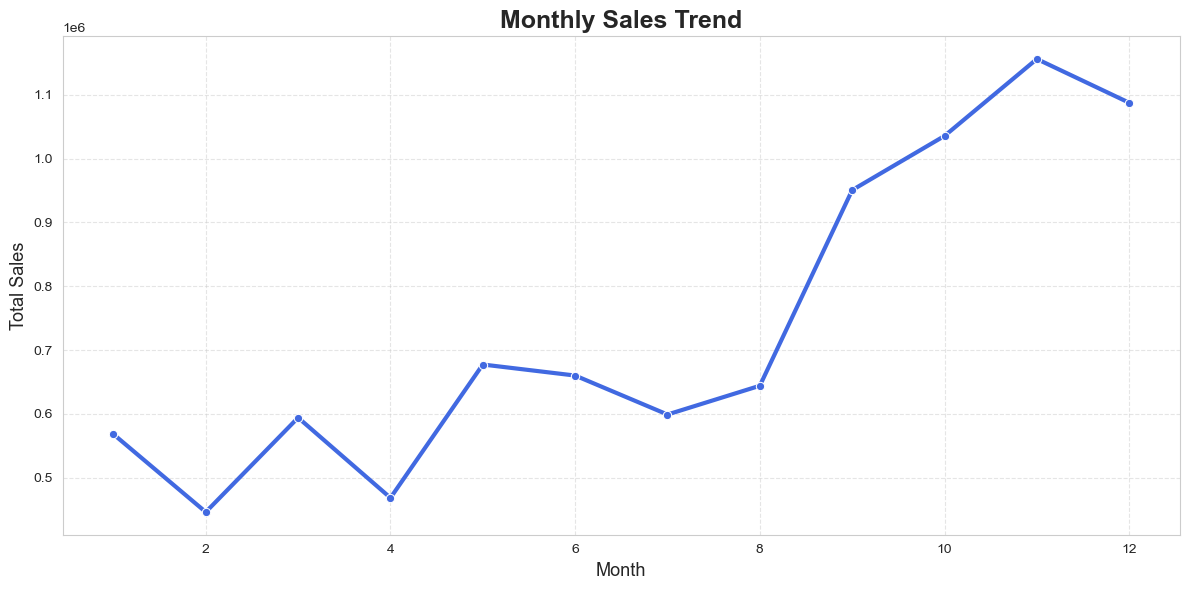

In [232]:
sns.set_style("whitegrid")

monthly_sales = df.groupby('month')['totalprice'].sum()

plt.figure(figsize=(12,6))

sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values,
    marker='o',
    linewidth=3,
    color='royalblue'
)

plt.title(
    'Monthly Sales Trend',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Month', fontsize=13)
plt.ylabel('Total Sales', fontsize=13)

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Top 10 Best-Selling Products
Bar chart ranking products by total quantity sold to identify high-demand inventory items.

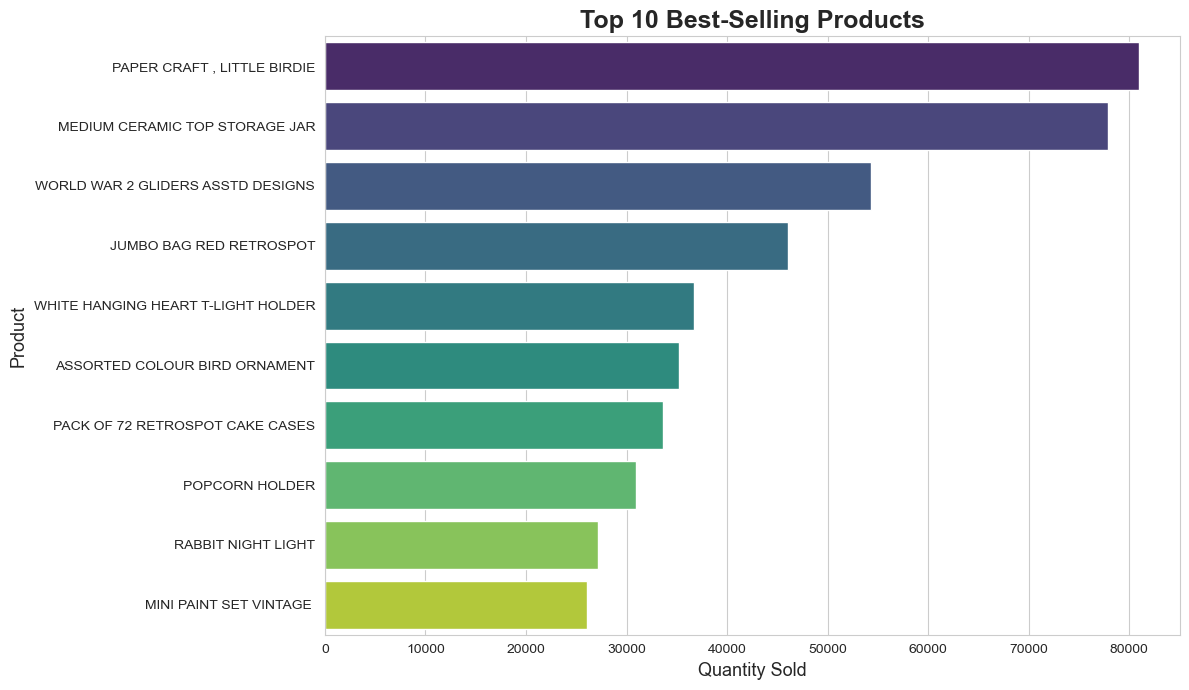

In [234]:
top_products = (
    df.groupby('description')['quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,7))

sns.barplot(
    x=top_products.values,
    y=top_products.index,
    palette='viridis'
)

plt.title(
    'Top 10 Best-Selling Products',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Quantity Sold', fontsize=13)
plt.ylabel('Product', fontsize=13)

plt.tight_layout()
plt.show()

### Top 10 Countries by Sales
Bar chart showing revenue by country to identify key markets.

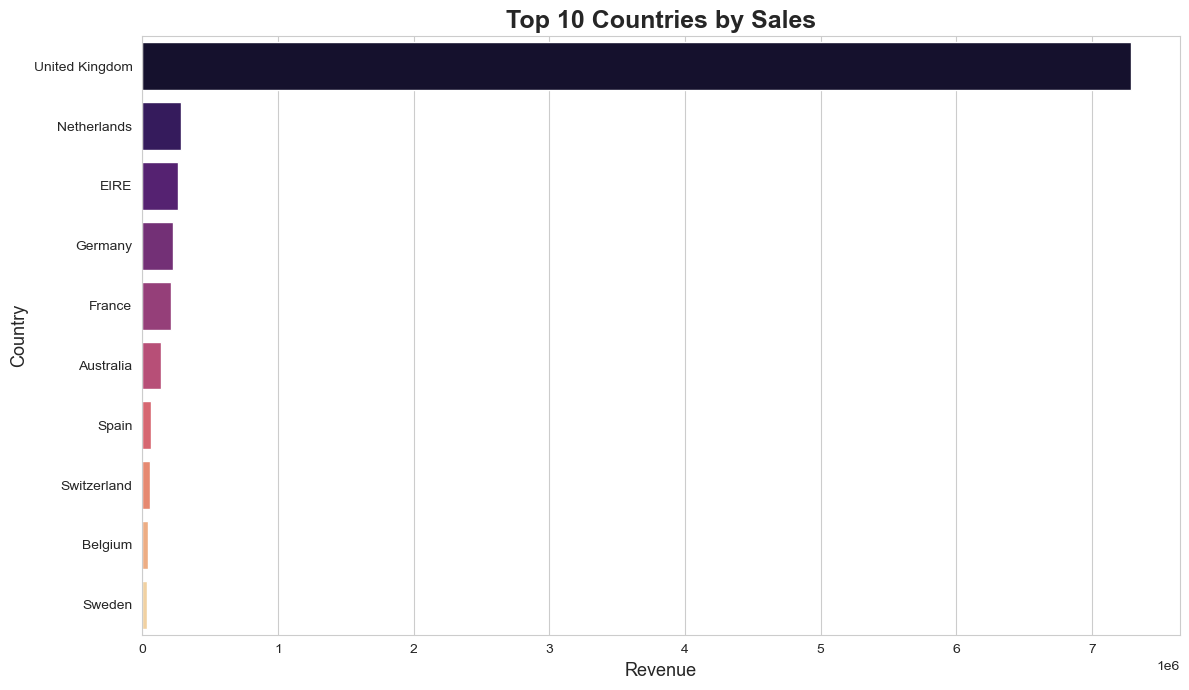

In [236]:
country_sales = (
    df.groupby('country')['totalprice']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,7))

sns.barplot(
    x=country_sales.values,
    y=country_sales.index,
    palette='magma'
)

plt.title(
    'Top 10 Countries by Sales',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Revenue', fontsize=13)
plt.ylabel('Country', fontsize=13)

plt.tight_layout()
plt.show()

### Orders by Day of Week
Bar chart showing order frequency per weekday to identify busiest shopping days.

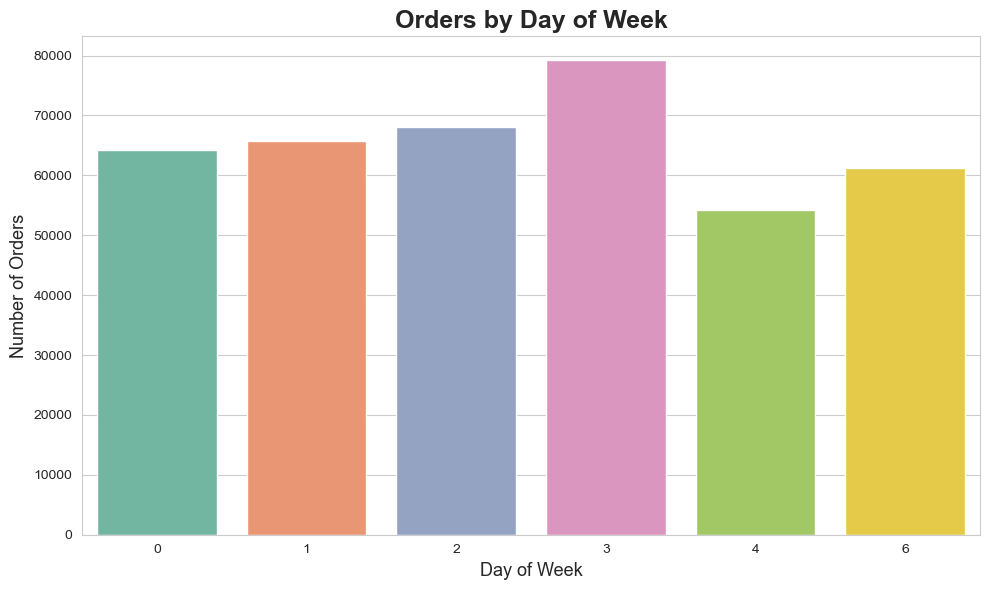

In [238]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='dayofweek',
    data=df,
    palette='Set2'
)

plt.title(
    'Orders by Day of Week',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Day of Week', fontsize=13)
plt.ylabel('Number of Orders', fontsize=13)

plt.tight_layout()
plt.show()

### Feature Correlation Heatmap
Heatmap showing correlation between quantity, unit price, and total price.

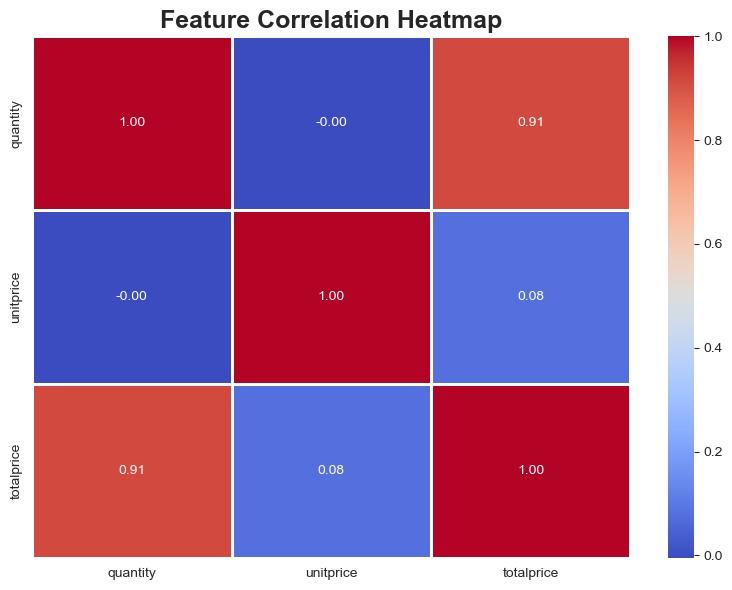

In [240]:
plt.figure(figsize=(8,6))

corr = df[['quantity', 'unitprice', 'totalprice']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    linewidths=1,
    fmt='.2f'
)

plt.title(
    'Feature Correlation Heatmap',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

### Daily Sales Trend
Line chart showing total sales per day to spot short-term fluctuations and seasonal patterns.

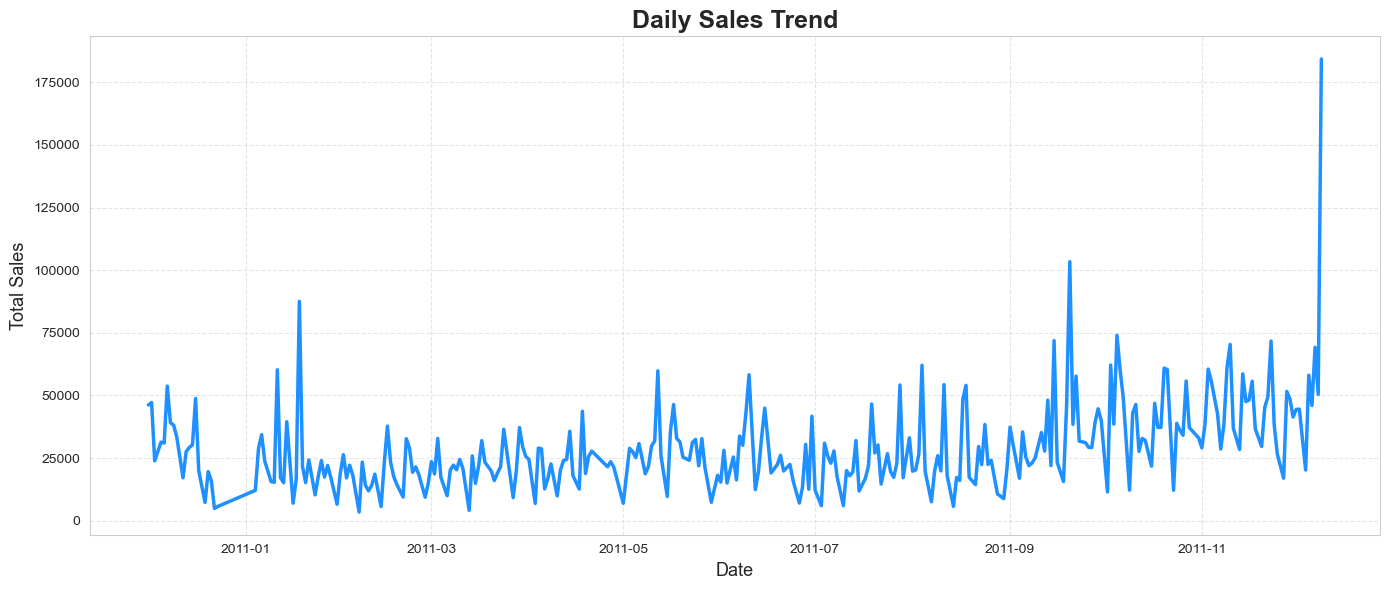

In [242]:
daily_sales = df.groupby(df['invoicedate'].dt.date)['totalprice'].sum()

plt.figure(figsize=(14,6))

sns.lineplot(
    x=daily_sales.index,
    y=daily_sales.values,
    color='dodgerblue',
    linewidth=2.5
)

plt.title(
    'Daily Sales Trend',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Date', fontsize=13)
plt.ylabel('Total Sales', fontsize=13)

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Top 10 Customers by Spending
Bar chart ranking customers by total spend to identify high-value customers.

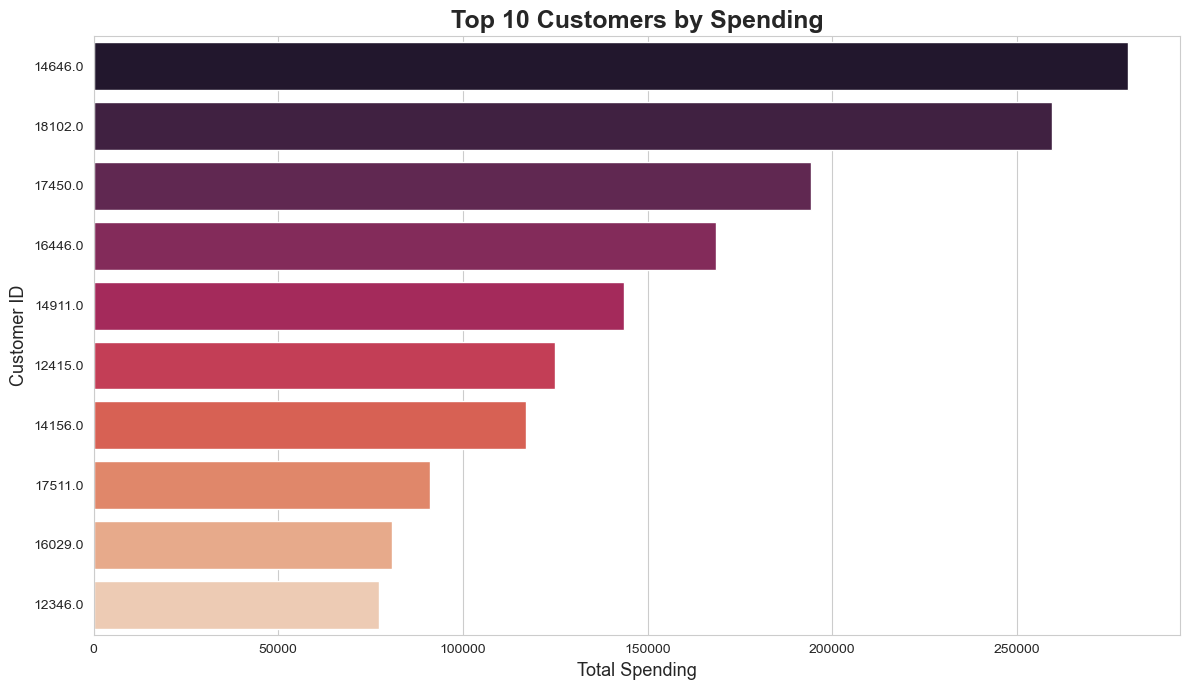

In [247]:
top_customers = (
    df.groupby('customerid')['totalprice']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,7))

sns.barplot(
    x=top_customers.values,
    y=top_customers.index.astype(str),
    palette='rocket'
)

plt.title(
    'Top 10 Customers by Spending',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Total Spending', fontsize=13)
plt.ylabel('Customer ID', fontsize=13)

plt.tight_layout()
plt.show()

## Customer Segmentation Using RFM Analysis

**Objective:** Segment customers based on Recency (R), Frequency (F), and Monetary (M) 
values to identify high-value, frequent, and inactive customers for targeted marketing.

In [249]:
from sklearn.cluster import KMeans

In [251]:
reference_date = df['invoicedate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customerid').agg({
    'invoicedate': lambda x: (reference_date - x.max()).days,  # Recency (days)
    'invoiceno': 'nunique',  # Frequency (count of unique invoices)
    'totalprice': 'sum'  # Monetary (total spent)
}).reset_index()

rfm.rename(columns={'invoicedate': 'Recency', 'invoiceno': 'Frequency', 'totalprice': 'Monetary'}, inplace=True)

print(rfm.head())

   customerid  Recency  Frequency  Monetary
0     12346.0      326          1  77183.60
1     12347.0        2          7   4310.00
2     12348.0       75          4   1797.24
3     12349.0       19          1   1757.55
4     12350.0      310          1    334.40


### Normalize RFM Scores
Standardizing Recency, Frequency, and Monetary values using StandardScaler for unbiased clustering.

In [253]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])


### Apply K-Means ++ Clustering
Grouping customers into distinct segments based on normalized RFM scores to identify behavioural patterns.

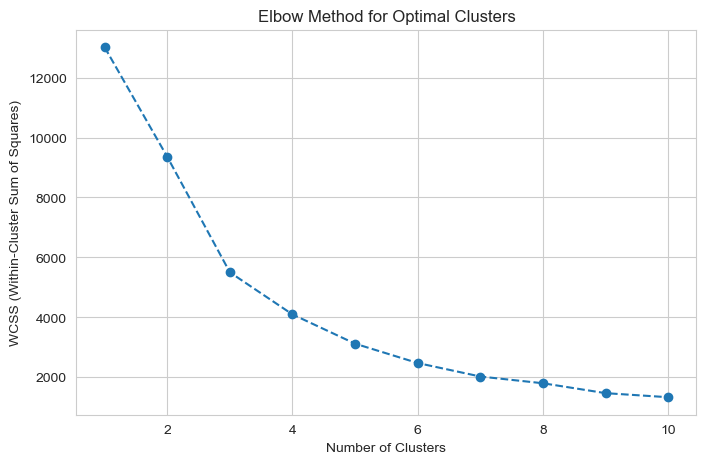

In [255]:
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.title('Elbow Method for Optimal Clusters')
plt.show()


### Elbow Method — Optimal k=4
WCSS drops sharply until k=4, after which improvement flattens. Selecting k=4 as optimal cluster count.

### Train K-Means Model
Fitting K-Means with k=4 on normalized RFM scores and assigning cluster labels to each customer.

In [259]:
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print(rfm.groupby('Cluster').agg({'Recency': 'mean', 'Frequency': 'mean', 'Monetary': 'mean'}))


            Recency  Frequency       Monetary
Cluster                                      
0         43.702685   3.682711    1353.625311
1        248.075914   1.552015     478.848772
2          7.384615  82.538462  127187.959231
3         15.500000  22.333333   12690.500392


### Cluster Analysis
| Cluster | Profile | Recency | Frequency | Monetary |
|---------|---------|---------|-----------|----------|
| 0 | Regular Customers | ~44 days | ~4 orders | ~£1,354 |
| 1 | Inactive/Lost | ~248 days | ~2 orders | ~£479 |
| 2 | VIP / Champions | ~7 days | ~83 orders | ~£127,188 |
| 3 | Loyal High-Spenders | ~16 days | ~22 orders | ~£12,691 |

### RFM Customer Segmentation Bubble Chart
Scatter plot of Recency vs Monetary (log scale) with bubble size as Frequency, visualizing 4 customer segments.

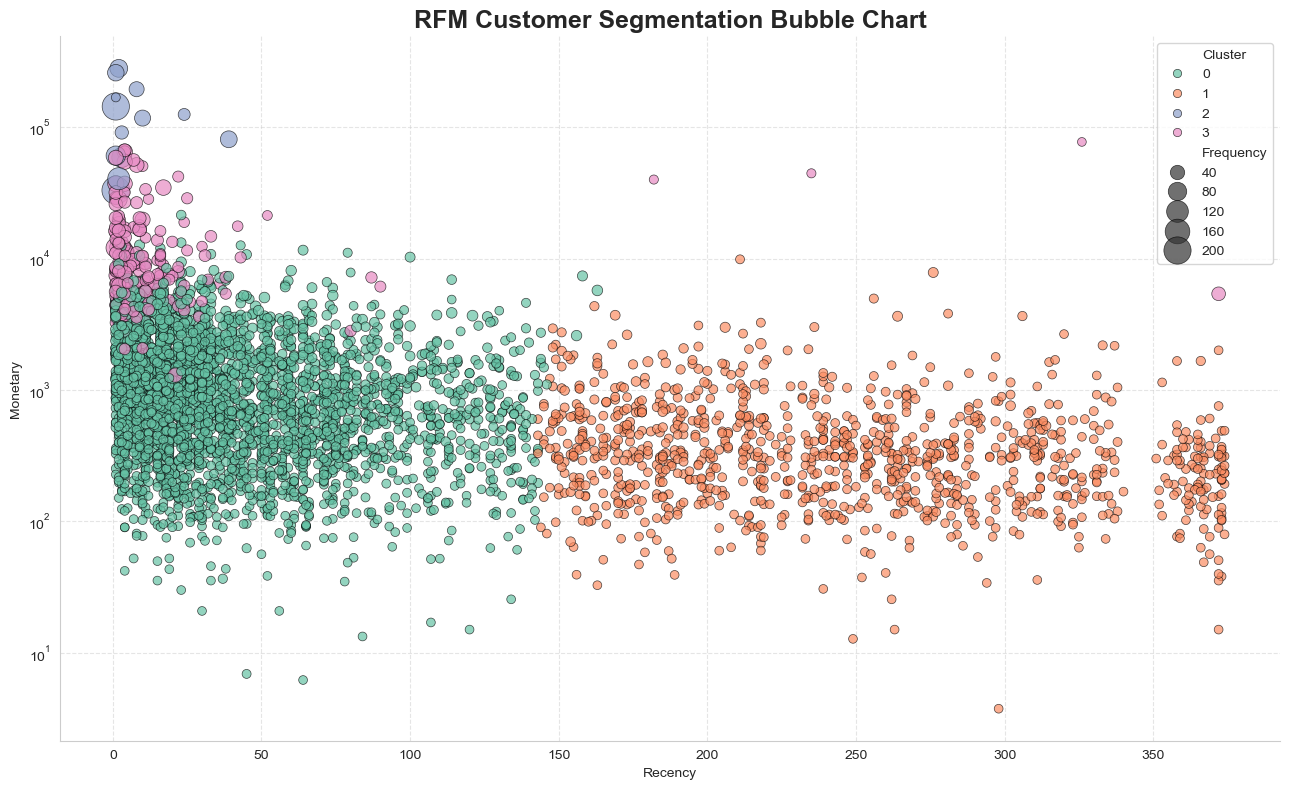

In [263]:
plt.figure(figsize=(13,8))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    size='Frequency',
    hue='Cluster',
    palette='Set2',
    sizes=(40, 400),
    alpha=0.7,
    edgecolor='black'
)

plt.title(
    'RFM Customer Segmentation Bubble Chart',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Recency')
plt.ylabel('Monetary')

plt.yscale('log')

plt.grid(True, linestyle='--', alpha=0.5)

sns.despine()
plt.tight_layout()
plt.show()

### Conclusion
The visualization reveals distinct customer segments based on Recency and Monetary values. 
High-spending customers tend to have low Recency (frequent buyers), while low-spending 
customers show high Recency, indicating inactivity.

## Sales Trend Analysis & Forecasting

### Load & Prepare Data
Aggregating daily total sales from cleaned retail data to build a time series for demand forecasting.

In [266]:
sales_data = df.groupby(df['invoicedate'].dt.date)['totalprice'].sum().reset_index()
sales_data.columns = ['date', 'totalprice']

sales_data['date'] = pd.to_datetime(sales_data['date'])
sales_data.set_index('date', inplace=True)

### Daily Sales Trend with 7-Day Rolling Average
Plotting daily sales alongside 7-day rolling average to smooth noise and highlight underlying demand trends.

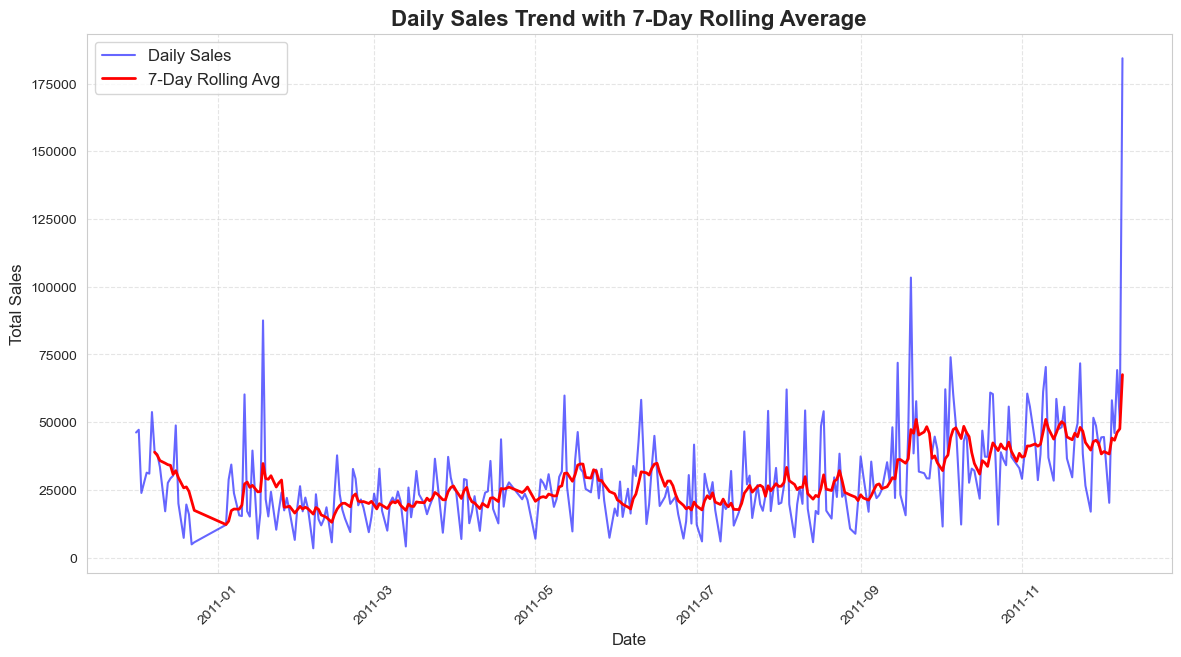

In [273]:
sales_data['RollingAvg'] = sales_data['totalprice'].rolling(window=7).mean()

plt.figure(figsize=(14, 7))
sns.lineplot(data=sales_data, x=sales_data.index, y='totalprice', color='blue', label='Daily Sales', alpha=0.6)
sns.lineplot(data=sales_data, x=sales_data.index, y='RollingAvg', color='red', label='7-Day Rolling Avg', linewidth=2)

plt.title("Daily Sales Trend with 7-Day Rolling Average", fontsize=16, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)

plt.legend(loc='upper left', fontsize=12)
plt.show()

### ARIMA Sales Forecasting
Fitting ARIMA model on daily sales and forecasting next 90 days demand to support inventory planning.

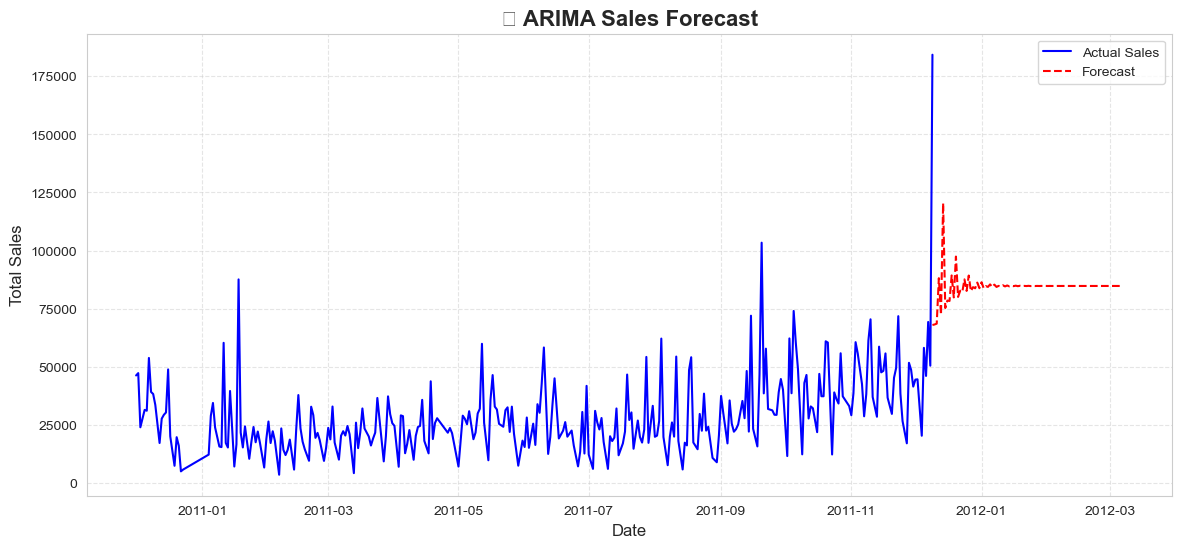

In [280]:
from statsmodels.tsa.arima.model import ARIMA
sales_data.index = pd.to_datetime(sales_data.index)

model = ARIMA(sales_data['totalprice'], order=(5,1,2))  
arima_result = model.fit()

forecast = arima_result.forecast(steps=90)

plt.figure(figsize=(14, 6))
plt.plot(sales_data.index, sales_data['totalprice'], label="Actual Sales", color="blue")
plt.plot(pd.date_range(sales_data.index[-1], periods=90, freq='D'), forecast, label="Forecast", color="red", linestyle="dashed")
plt.title("ARIMA Sales Forecast", fontsize=16, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## Product Recommendation System

### User-Based Collaborative Filtering
Building a User-Item matrix from purchase history and computing cosine similarity between customers to find the top 5 most similar users for product recommendations.

In [140]:
from sklearn.metrics.pairwise import cosine_similarity

user_item_matrix = df.pivot_table(index='customerid', columns='stockcode', values='quantity', fill_value=0)

user_similarity = cosine_similarity(user_item_matrix)

user_similarity_df = pd.DataFrame(user_similarity, index=user_item_matrix.index, columns=user_item_matrix.index)

def get_similar_users(customer_id, n=5):
    return user_similarity_df[customer_id].sort_values(ascending=False).iloc[1:n+1]

similar_users = get_similar_users(customer_id=17850, n=5)
print(similar_users)


customerid
13161.0    0.386039
18105.0    0.304348
13831.0    0.288015
13514.0    0.266867
17616.0    0.265025
Name: 17850.0, dtype: float64


### Similar Users Result
Top 5 customers most similar to Customer 17850 based on purchase behaviour, ranked by cosine similarity score.

## Conclusion

This project successfully built an end-to-end **Inventory Demand Forecasting and Product Recommendation System** using real-world retail data.

- **Data Cleaning** removed duplicates, nulls, cancellations, and invalid transactions ensuring data quality.
- **EDA** revealed strong seasonality with peak sales in Q4 (Oct–Dec) and identified top products and high-value customers.
- **RFM Segmentation** clustered customers into 4 groups — VIP, Loyal, Regular, and Inactive — enabling targeted marketing.
- **ARIMA Forecasting** modelled daily sales trends and predicted next 90 days demand to support inventory planning.
- **Recommendation System** used cosine similarity on purchase history to identify similar customers for product recommendations.

Overall, this system enables businesses to reduce stockouts, minimize overstocking, and improve customer retention through data-driven decisions.